In [2]:
from IPython.display import display, Latex
from IPython.core.display import HTML
%reset -f
%matplotlib inline
%autosave 300

Autosaving every 300 seconds


In [3]:
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags
import sympy as sy
from numpy import linspace, ones
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.pylab import *
from time import time
from mpl_toolkits import mplot3d
from scipy.fftpack import rfft, irfft, dst, dct, idst

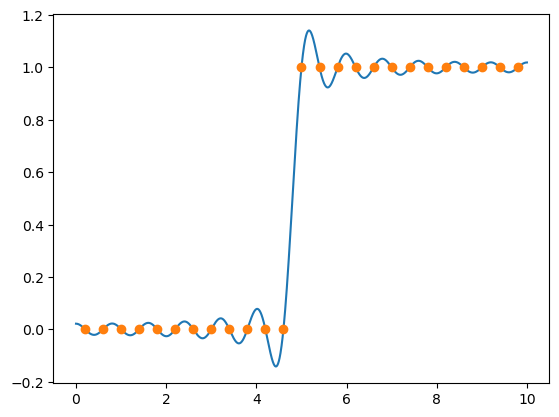

In [4]:
N = 25
L = 10
dx = L/N
x = np.linspace(dx/2, L-dx/2, N)
U = np.zeros(N)
U[N//2:] = 1
#U[N//4:N//2]= 0
#U[N//2] = 1/2
#U[N//2 + 1] = 3/4
U_chap = dct(U)

phi_0 = 1/(2*N)
phi_k = lambda  k: (1/N)*np.cos(np.pi*k*(X_fin/L))

X_fin = np.linspace(0, L, 3000)
U_fin = U_chap[0] * phi_0
for k in range(1, N):
    U_fin += U_chap[k] * phi_k(k)

#U_fin = sum(for U_chapk, k in enumerate(U_chap) if k == 0 )

plt.plot(X_fin,U_fin)
plt.plot(x, U, 'o')

    


In [21]:
U0 = lambda x, L: np.exp(-(x-L/2)**2 / ((10**-2) * (L/2)**2))
lambda_k = lambda k, L : ((k + 1) * np.pi / L)**2

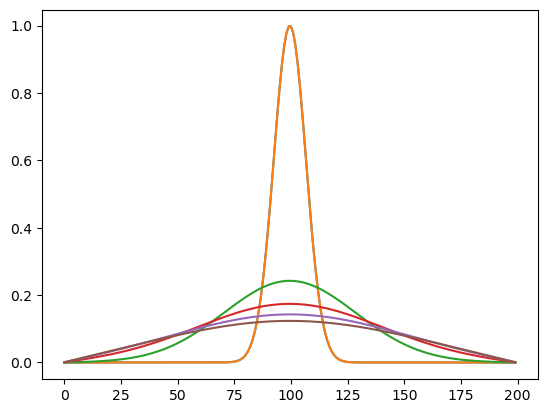

In [22]:
# Homogène
N = 200
L = 10
dx = L/N
x = np.linspace(dx/2, L-dx/2, N)
U = np.zeros(N)
U = U0(x, L)
U_chap = dst(U)
plt.plot(U)
for t in range(5):
    U_final = []
    for k, uk in enumerate(U_chap):
        U_final.append(uk * np.exp(-lambda_k(k, L) * t))
    U_final = idst(U_final) * 0.5/N
    plt.plot(U_final)


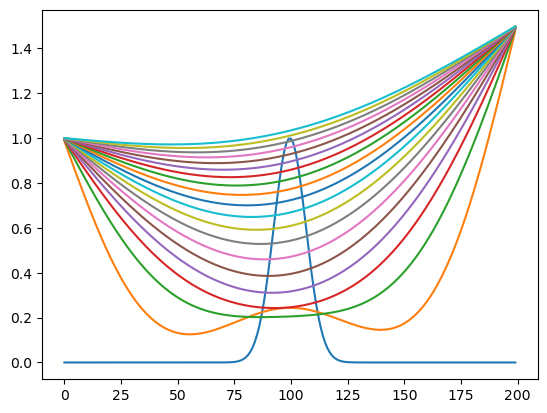

In [25]:
# Inhomogène
a = 1
b = 1.5
N = 200
L = 10
dx = L/N
x = np.linspace(dx/2, L-dx/2, N)
U = np.zeros(N)
U = U0(x, L)

V = U -( a + (b-a)/L*x)
V_chap = dst(V)

for t in range(20):
    V_final = []
    for k, vk in enumerate(V_chap):
        V_final.append(vk * np.exp(-lambda_k(k, L) * t))
    V_final = idst(V_final) * (0.5/N)
    U_final = V_final +a + (b-a)/L*x
    #U_final = a + (b-a)/L*x
    plt.plot(U_final)